In [38]:
import torch
data = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.001_results.pt", weights_only=False)
theta_stars = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.001_phi_oracle_hist.pt", weights_only=False)

In [39]:
phi_hist, oracle_hist, _ = theta_stars

In [6]:
data["BPC-BOCPD"].keys()

dict_keys(['theta', 'theta_oracle', 'others', 'rmse'])

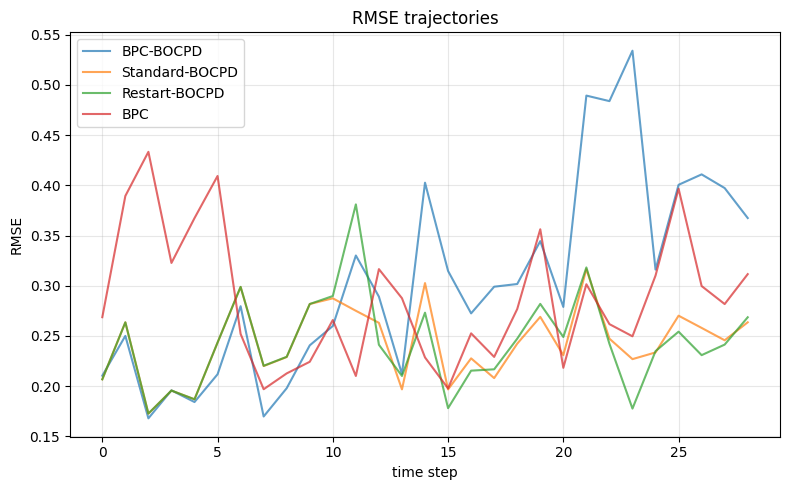

['BPC-BOCPD', 'Standard-BOCPD', 'Restart-BOCPD', 'BPC']
[0.30388321 0.24343526 0.24312915 0.28718998] [0.00952849 0.00131384 0.00202744 0.00420968] [0.09761396 0.03624696 0.04502715 0.06488205]


In [40]:
import numpy as np
import matplotlib.pyplot as plt

rmse_list = [data[name]["rmse"] for name in data.keys()]
names = [name for name in data.keys()]

plt.figure(figsize=(8, 5))

for i, rmse in enumerate(rmse_list):
    plt.plot(rmse, alpha=0.7, label=names[i])

plt.xlabel("time step")
plt.ylabel("RMSE")
plt.title("RMSE trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rmse_mat = np.stack(rmse_list, axis=0)  # shape = (N_runs, T)
rmse_mean = rmse_mat.mean(axis=1)   # shape (T,)
rmse_var  = rmse_mat.var(axis=1)    # shape (T,)
rmse_std  = rmse_mat.std(axis=1)
print(names)
print(rmse_mean, rmse_var, rmse_std)

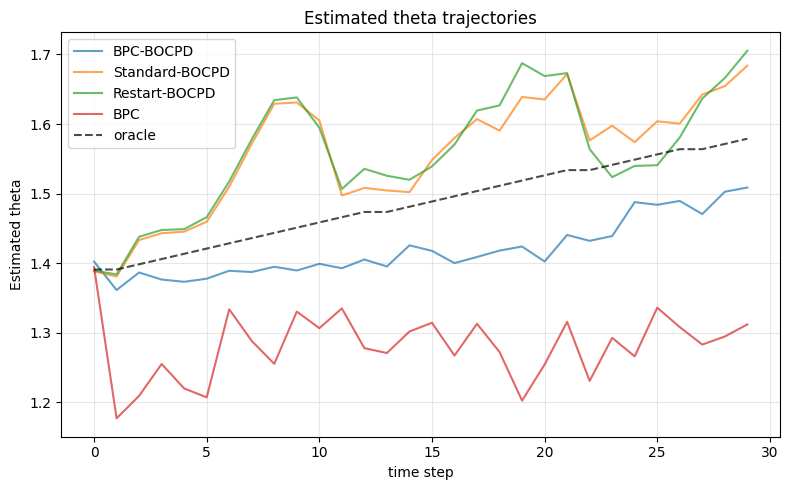

In [41]:
theta_list = []
for n in names:
    theta_list.append(data[n]['theta'])

plt.figure(figsize=(8, 5))

for i, theta in enumerate(theta_list):
    plt.plot(theta, alpha=0.7, label=names[i])

plt.plot(np.array(oracle_hist), alpha=0.7, label="oracle", color="black", linestyle="dashed")

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Estimated theta trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
theta_rmse_all = {}

for n in names:
    theta_n = np.asarray(data[n]["theta"])
    theta_rmse_all[n] = np.sqrt(np.mean((theta_n - oracle_hist) ** 2))

for k, v in theta_rmse_all.items():
    print(f"{k}: theta RMSE = {v:.4f}")


BPC-BOCPD: theta RMSE = 0.0723
Standard-BOCPD: theta RMSE = 0.0872
Restart-BOCPD: theta RMSE = 0.0948
BPC: theta RMSE = 0.2154


In [43]:
for n in names:
    try:
        others = data[n]["others"]

        lo = np.array([o["lo"] for o in others])
        hi = np.array([o["hi"] for o in others])
        oracle = np.asarray(oracle_hist)

        coverage = np.mean((oracle >= lo) & (oracle <= hi))
        print(f"{n}'s 90% coverage:", coverage)
    except:
        continue


BPC-BOCPD's 90% coverage: 0.051111111111111114
Standard-BOCPD's 90% coverage: 0.3333333333333333
Restart-BOCPD's 90% coverage: 0.3333333333333333


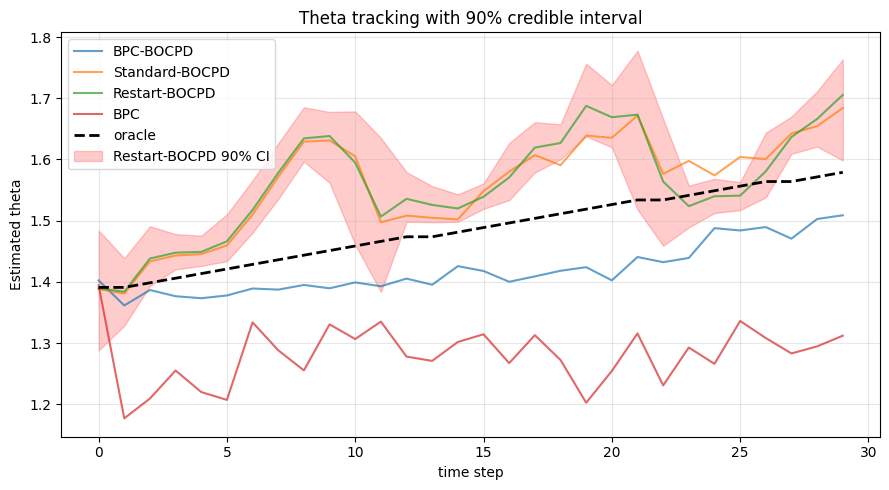

In [44]:
plt.figure(figsize=(9, 5))

# -------- point estimates --------
for i, n in enumerate(names):
    plt.plot(
        data[n]["theta"],
        alpha=0.7,
        label=n
    )

# -------- oracle --------
plt.plot(
    oracle_hist,
    color="black",
    linestyle="dashed",
    lw=2,
    label="oracle"
)

# -------- 90% credible interval (Restart-BOCPD) --------
others = data["Restart-BOCPD"]["others"]
lo = np.array([o["lo"] for o in others])
hi = np.array([o["hi"] for o in others])

t = np.arange(len(lo))
plt.fill_between(
    t,
    lo,
    hi,
    color="red",
    alpha=0.2,
    label="Restart-BOCPD 90% CI"
)

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Theta tracking with 90% credible interval")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
def extract_theta_and_ci(data_method, oracle_hist):
    """
    data_method: data[name]
    oracle_hist: (T,)
    
    returns:
        theta: (T,)
        lo: (T,) or None
        hi: (T,) or None
    """
    theta = np.asarray(data_method["theta"])
    T = len(theta)

    if "others" in data_method and len(data_method["others"]) == T:
        o0 = data_method["others"][0]
        if isinstance(o0, dict) and "lo" in o0 and "hi" in o0:
            lo = np.array([o["lo"] for o in data_method["others"]])
            hi = np.array([o["hi"] for o in data_method["others"]])
            return theta, lo, hi

    return theta, None, None


BPC-BOCPD       coverage = 0.051
Standard-BOCPD  coverage = 0.333
Restart-BOCPD   coverage = 0.333
BPC             coverage = N/A


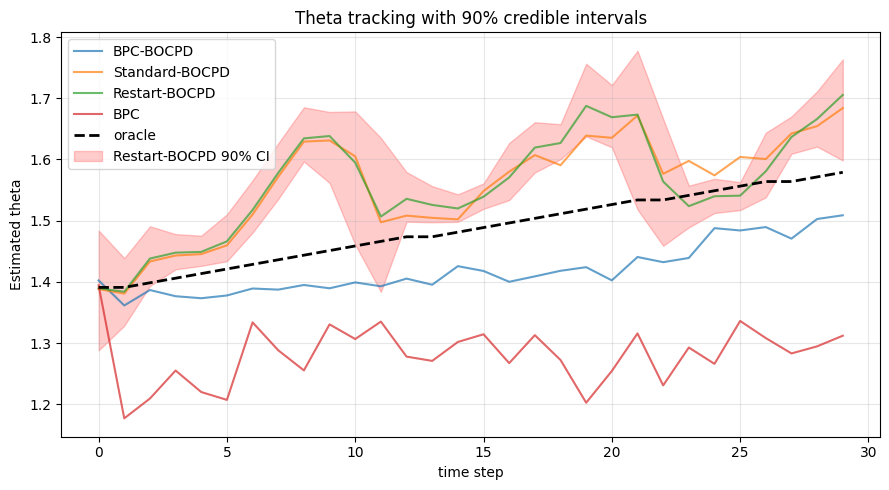

In [48]:
coverage_all = {}

for n in names:
    theta, lo, hi = extract_theta_and_ci(data[n], oracle_hist)
    if lo is None:
        coverage_all[n] = None
        continue

    oracle = oracle_hist[:len(theta)]
    coverage_all[n] = np.mean((oracle >= lo) & (oracle <= hi))

for k, v in coverage_all.items():
    if v is None:
        print(f"{k:15s} coverage = N/A")
    else:
        print(f"{k:15s} coverage = {v:.3f}")

plt.figure(figsize=(9, 5))

# -------- point estimates --------
for n in names:
    plt.plot(
        data[n]["theta"],
        alpha=0.7,
        label=n
    )

# -------- oracle --------
plt.plot(
    oracle_hist,
    color="black",
    linestyle="dashed",
    lw=2,
    label="oracle"
)

# -------- Restart-BOCPD CI --------
if "Restart-BOCPD" in data:
    _, lo_r, hi_r = extract_theta_and_ci(
        data["Restart-BOCPD"], oracle_hist
    )
    if lo_r is not None:
        t = np.arange(len(lo_r))
        plt.fill_between(
            t,
            lo_r,
            hi_r,
            color="red",
            alpha=0.2,
            label="Restart-BOCPD 90% CI"
        )

# -------- BPC-BOCPD CI --------
# if "BPC-BOCPD" in data:
#     _, lo_b, hi_b = extract_theta_and_ci(
#         data["BPC-BOCPD"], oracle_hist
#     )
#     if lo_b is not None:
#         lo_b = np.asarray(lo_b).squeeze()
#         hi_b = np.asarray(hi_b).squeeze()
        
#         t = np.arange(len(lo_b))
#         plt.fill_between(
#             t,
#             lo_b,
#             hi_b,
#             color="blue",
#             alpha=0.2,
#             label="BPC-BOCPD 90% CI"
#         )
# if "BPC-BOCPD" in data:
#     # 提取 mean / var
#     theta_mean = np.asarray(data["BPC-BOCPD"]["theta"]).squeeze()

#     # others[i]["var"] 可能是 scalar 或 array，统一成 1D
#     theta_var = np.array([
#         float(o["var"]) for o in data["BPC-BOCPD"]["others"]
#     ])

#     theta_std = np.sqrt(theta_var)

#     lo_b = theta_mean - 2.0 * theta_std
#     hi_b = theta_mean + 2.0 * theta_std

#     t = np.arange(len(theta_mean))
#     plt.fill_between(
#         t,
#         lo_b,
#         hi_b,
#         color="blue",
#         alpha=0.2,
#         label="BPC-BOCPD mean ± 2 std"
#     )

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Theta tracking with 90% credible intervals")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [57]:
for name in ["Restart-BOCPD", "Standard-BOCPD"]:
    lst = [x["did_restart"] for x in data[name]["others"]]
    count_true = sum(lst)
    avg_interval = len(lst)/count_true
    print(name, count_true, avg_interval)

Restart-BOCPD 2 15.0
Standard-BOCPD 7 4.285714285714286


In [170]:
import torch
prefix = "v6_merge"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_results.pt", weights_only=False)

color_map = {
    # ---- PF / BOCPD-PF variants ----
    "BOCPD-PF": "#1f77b4",                    # blue
    "R-BOCPD-PF": "#2ca02c",                  # green
    "R-BOCPD-PF-nodiscrepancy": "#ff7f0e",    # orange
    "R-BOCPD-PF-usediscrepancy": "#9467bd",   # purple

    # ---- BPC family ----
    "BPC-80": "#d62728",                      # red
    "BOCPD-BPC": "#8c564b",                   # brown
}




In [168]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (slope, bc, seed), res in results.items():
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]

        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                slope=slope,
                batch_size=bc,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                # restart_count=count_true if name=="Restart-BOCPD" else np.nan,
                # avg_restart_interval=avg_interval if name=="Restart-BOCPD" else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
            ))
    return pd.DataFrame(rows)

df = flatten_results(results)
print(df.head())


   slope  batch_size  seed                     method  rmse_mean  rmse_std  \
0  0.001          10   456                  BOCPD-BPC   1.346412  0.101702   
1  0.001          10   456                   BOCPD-PF   1.390997  0.118578   
2  0.001          10   456                     BPC-80   1.339235  0.101660   
3  0.001          10   456   R-BOCPD-PF-nodiscrepancy   1.361083  0.105765   
4  0.001          10   456  R-BOCPD-PF-usediscrepancy   1.441060  0.143735   

   theta_rmse  coverage  restart_count  avg_restart_interval  
0    0.064928  0.054167            NaN                   NaN  
1    0.125296  0.266667            NaN                   NaN  
2    0.032822       NaN            NaN                   NaN  
3    0.029451  1.000000            0.0                   NaN  
4    0.175210  0.700000            2.0                  30.0  


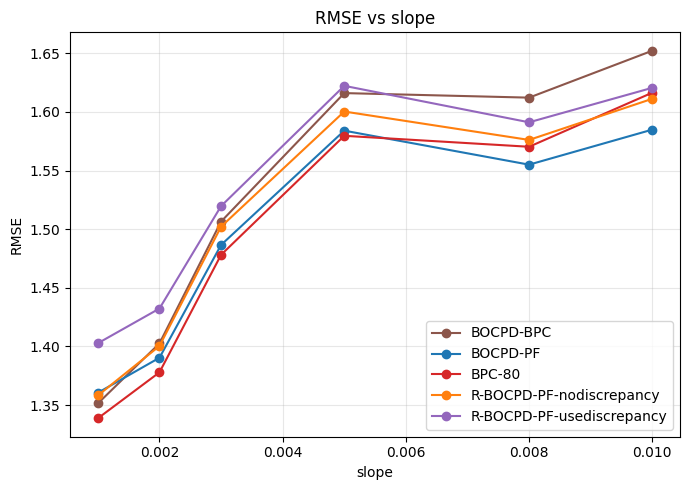

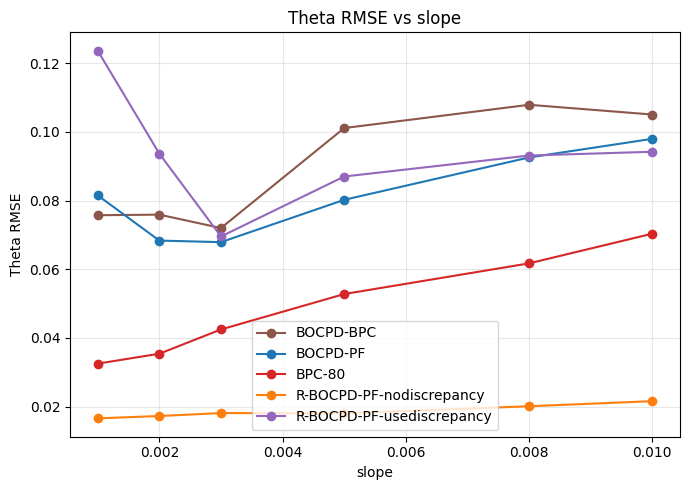

In [171]:
import matplotlib.pyplot as plt

def plot_metric_vs_slope(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("slope")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("slope")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_vs_slope(df, "rmse_mean", "RMSE")
plot_metric_vs_slope(df, "theta_rmse", "Theta RMSE")


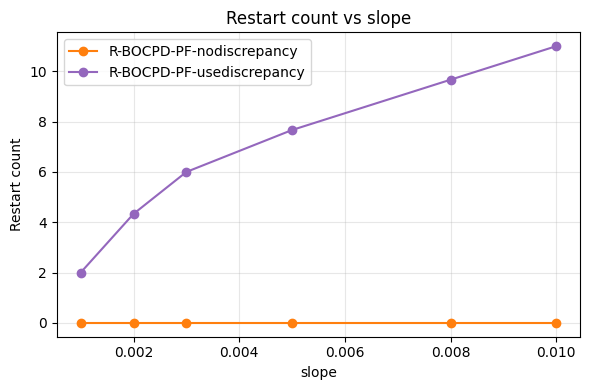

In [174]:
def plot_restart_vs_slope(df):
    d = df[df["method"]=="R-BOCPD-PF-nodiscrepancy"]
    g = d.groupby("slope")["restart_count"].mean()

    d1 = df[df["method"]=="R-BOCPD-PF-usediscrepancy"]
    g1 = d1.groupby("slope")["restart_count"].mean()

    plt.figure(figsize=(6,4))
    plt.plot(g.index, g.values, marker="o", label="R-BOCPD-PF-nodiscrepancy", color=color_map["R-BOCPD-PF-nodiscrepancy"])
    plt.plot(g1.index, g1.values, marker="o", label="R-BOCPD-PF-usediscrepancy", color=color_map["R-BOCPD-PF-usediscrepancy"])
    plt.xlabel("slope")
    plt.ylabel("Restart count")
    plt.title("Restart count vs slope")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_restart_vs_slope(df)


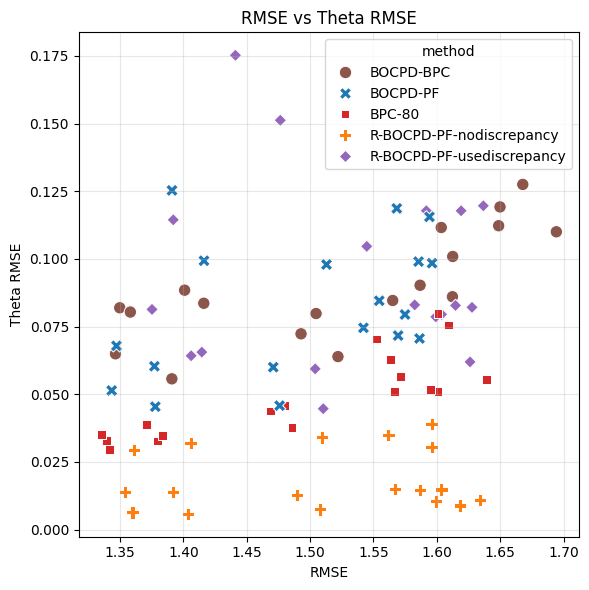

In [175]:
import seaborn as sns

def scatter_rmse_theta(df):
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        data=df,
        x="rmse_mean",
        y="theta_rmse",
        hue="method",
        style="method",
        s=80,
        palette=color_map
    )
    plt.xlabel("RMSE")
    plt.ylabel("Theta RMSE")
    plt.title("RMSE vs Theta RMSE")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

scatter_rmse_theta(df)


In [176]:
def compute_rank(df, metric):
    ranks = []
    for slope in df["slope"].unique():
        d = df[df["slope"]==slope]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                slope=slope,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank(df, "rmse_mean")
rank_theta = compute_rank(df, "theta_rmse")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
BPC-80                       1.500000
BOCPD-PF                     2.000000
R-BOCPD-PF-nodiscrepancy     2.833333
BOCPD-BPC                    4.000000
R-BOCPD-PF-usediscrepancy    4.666667
Name: rank, dtype: float64

Theta RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.000000
BPC-80                       2.000000
BOCPD-PF                     3.333333
R-BOCPD-PF-usediscrepancy    4.166667
BOCPD-BPC                    4.500000
Name: rank, dtype: float64


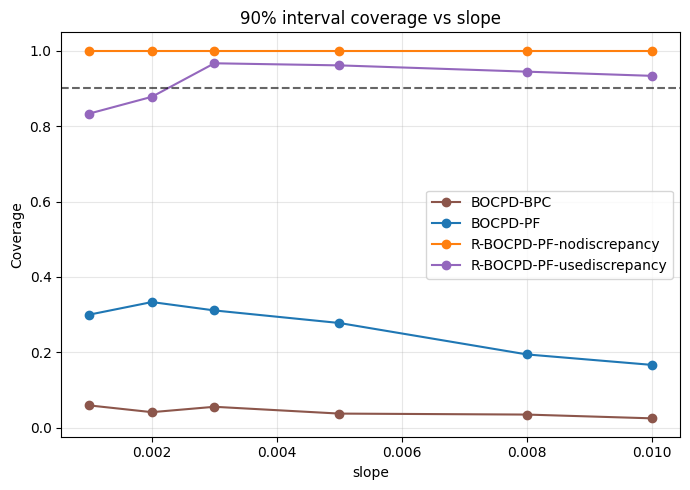

In [177]:
def plot_coverage(df):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        # method = "Restart-BOCPD"
        d = df[df["method"]==method]
        if d["coverage"].isna().all():
            continue
        m = d.groupby("slope")["coverage"].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])
    # method = "Restart-BOCPD"
    # d = df[df["method"]==method]
    # # if d["coverage"].isna().all():
    # #     continue
    # m = d.groupby("slope")["coverage"].mean()
    # plt.plot(m.index, m.values, marker="o", label=method)

    plt.axhline(0.9, color="k", linestyle="--", alpha=0.6)
    plt.xlabel("slope")
    plt.ylabel("Coverage")
    plt.title("90% interval coverage vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_coverage(df)


In [91]:
df

,slope,batch_size,seed,method,rmse_mean,rmse_std,theta_rmse,coverage,restart_count,avg_restart_interval
0,0.001,20,456,BPC-BOCPD,0.305974,0.087762,0.062366,0.054444,NaN,NaN
1,0.001,20,456,Standard-BOCPD,0.237596,0.038634,0.105137,0.266667,NaN,NaN
2,0.001,20,456,Restart-BOCPD,0.228762,0.037224,0.103449,0.266667,3.0,10.000000
3,0.001,20,456,BPC,0.283432,0.078345,0.211136,NaN,NaN,NaN
4,0.001,40,456,BPC-BOCPD,0.359598,0.102758,0.074586,0.053333,NaN,NaN
5,0.001,40,456,Standard-BOCPD,0.270368,0.034220,0.069147,0.200000,NaN,NaN
6,0.001,40,456,Restart-BOCPD,0.257852,0.040808,0.048290,0.600000,3.0,5.000000
7,0.001,40,456,BPC,0.288762,0.041965,0.211573,NaN,NaN,NaN
8,0.002,20,456,BPC-BOCPD,0.419656,0.134013,0.049560,0.040000,NaN,NaN
9,0.002,20,456,Standard-BOCPD,0.265113,0.046424,0.072961,0.433333,NaN,NaN


In [72]:
debug_res = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.005_seed456_batch40_results.pt", weights_only=False)


In [124]:
phi = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_v6/slope_0.008_seed456_batch40_phi_oracle_hist.pt", weights_only=False)

In [125]:
phi

{'phi_hist': [array([5., 5., 5.]),
  array([5.  , 5.32, 5.  ]),
  array([5.  , 5.64, 5.  ]),
  array([5.  , 5.96, 5.  ]),
  array([5.  , 6.28, 5.  ]),
  array([5. , 6.6, 5. ]),
  array([5.  , 6.92, 5.  ]),
  array([5.  , 7.24, 5.  ]),
  array([5.  , 7.56, 5.  ]),
  array([5.  , 7.88, 5.  ]),
  array([5. , 8.2, 5. ]),
  array([5.  , 8.52, 5.  ]),
  array([5.  , 8.84, 5.  ]),
  array([5.  , 9.16, 5.  ]),
  array([5.  , 9.48, 5.  ])],
 'oracle_hist': [1.3909774436090225,
  1.4962406015037593,
  1.593984962406015,
  1.6616541353383458,
  1.706766917293233,
  1.7518796992481203,
  1.789473684210526,
  1.8345864661654134,
  1.8872180451127818,
  1.9548872180451127,
  2.037593984962406,
  2.1353383458646613,
  2.218045112781955,
  2.2857142857142856,
  2.338345864661654]}

In [80]:
debug_res["Restart-BOCPD"]['others'][-4:], debug_res["Restart-BOCPD"]['theta'][-4:]

([{'did_restart': False,
   'var': 0.0007023502944285244,
   'lo': 1.8348981142044067,
   'hi': 1.9172669513914835},
  {'did_restart': True,
   'var': 0.5966463821957984,
   'lo': 0.26110900613451404,
   'hi': 1.9133268129081158},
  {'did_restart': False,
   'var': 0.015478940596340482,
   'lo': 0.1709764007719303,
   'hi': 0.24189859628677368},
  {'did_restart': True,
   'var': 0.0016068974853185292,
   'lo': 1.898771355788596,
   'hi': 2.030345527194764}],
 array([1.87097415, 1.13691184, 0.21692365, 1.96626833]))

In [178]:
import torch
prefix = "v5_nodiscrepancy_usediscrepancy_merge"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_results.pt", weights_only=False)

In [179]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (seg_len_L, delta_mag, batch_size, seed), res in results.items():
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]
        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                seg_len_L=seg_len_L,
                delta_mag=delta_mag,
                batch_size=batch_size,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
            ))
    return pd.DataFrame(rows)

df = flatten_results(results)
print(df.head())


   seg_len_L  delta_mag  batch_size  seed                     method  \
0         40        0.5          20   456                   BOCPD-PF   
1         40        0.5          20   456                     BPC-80   
2         40        0.5          20   456                  BOCPD-BPC   
3         40        0.5          20   456   R-BOCPD-PF-nodiscrepancy   
4         40        0.5          20   456  R-BOCPD-PF-usediscrepancy   

   rmse_mean  rmse_std  theta_rmse  coverage  restart_count  \
0   1.700022  0.110010    0.104356     0.500            NaN   
1   1.688765  0.103855    0.091541     0.000            NaN   
2   1.710567  0.078093    0.127969     0.250            NaN   
3   1.686074  0.123358    0.014601     1.000            0.0   
4   1.726443  0.120666    0.103713     0.875            2.0   

   avg_restart_interval  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   4.0  


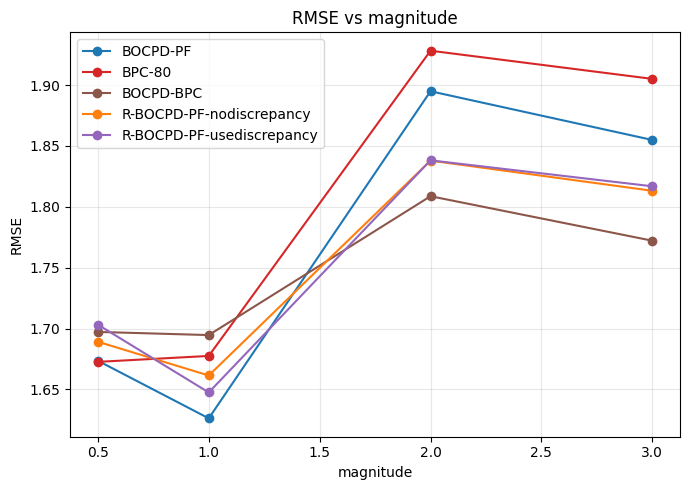

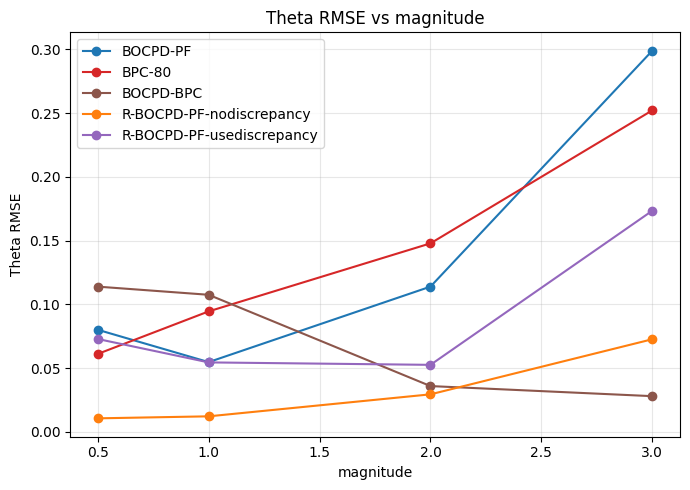

In [180]:
import matplotlib.pyplot as plt

def plot_metric_vs_magnitude(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("delta_mag")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("magnitude")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_vs_magnitude(df, "rmse_mean", "RMSE")
plot_metric_vs_magnitude(df, "theta_rmse", "Theta RMSE")


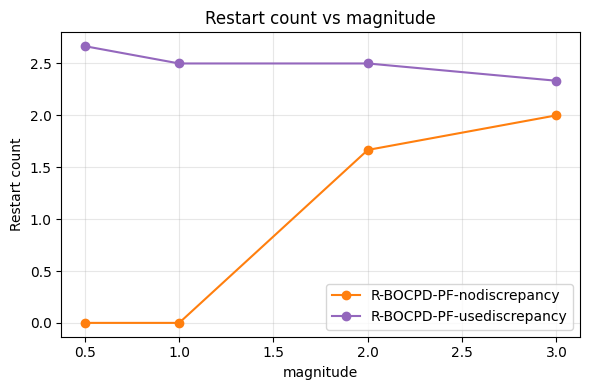

In [181]:
def plot_restart_vs_magnitude(df):
    d = df[df["method"]=="R-BOCPD-PF-nodiscrepancy"]
    g = d.groupby("delta_mag")["restart_count"].mean()
    d1 = df[df["method"]=="R-BOCPD-PF-usediscrepancy"]
    g1 = d1.groupby("delta_mag")["restart_count"].mean()

    plt.figure(figsize=(6,4))
    plt.plot(g.index, g.values, marker="o", label="R-BOCPD-PF-nodiscrepancy", color=color_map["R-BOCPD-PF-nodiscrepancy"])
    plt.plot(g1.index, g1.values, marker="o", label="R-BOCPD-PF-usediscrepancy", color=color_map["R-BOCPD-PF-usediscrepancy"])
    plt.xlabel("magnitude")
    plt.ylabel("Restart count")
    plt.title("Restart count vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_restart_vs_magnitude(df)


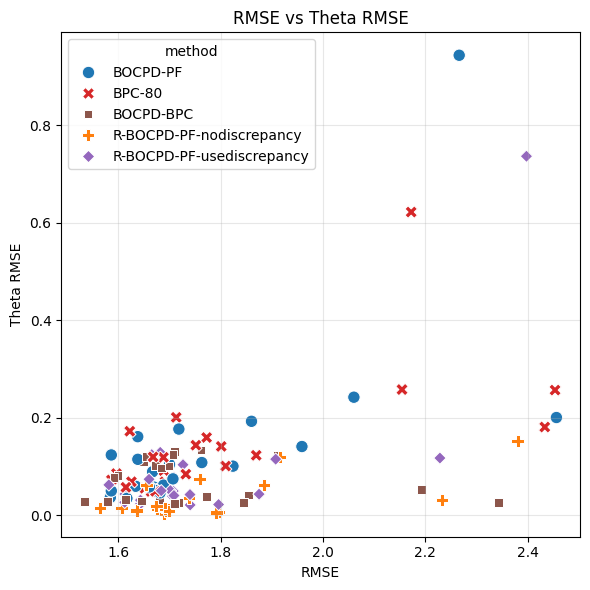

In [182]:
import seaborn as sns
scatter_rmse_theta(df)


In [183]:
def compute_rank_magnitude(df, metric):
    ranks = []
    for delta_mag in df["delta_mag"].unique():
        d = df[df["delta_mag"]==delta_mag]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                delta_mag=delta_mag,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank_magnitude(df, "rmse_mean")
rank_theta = compute_rank_magnitude(df, "theta_rmse")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     2.50
BOCPD-BPC                    2.75
BOCPD-PF                     2.75
R-BOCPD-PF-usediscrepancy    3.25
BPC-80                       3.75
Name: rank, dtype: float64

Theta RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.25
R-BOCPD-PF-usediscrepancy    2.75
BOCPD-BPC                    3.25
BPC-80                       3.75
BOCPD-PF                     4.00
Name: rank, dtype: float64


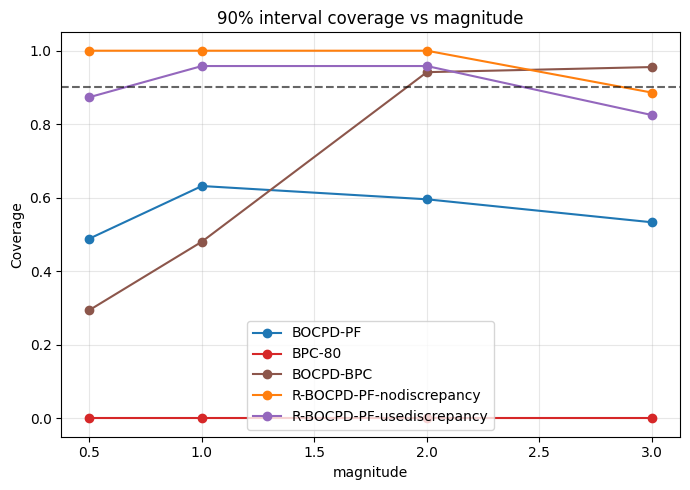

In [184]:
def plot_coverage_magnitude(df):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        # method = "Restart-BOCPD"
        d = df[df["method"]==method]
        if d["coverage"].isna().all():
            continue
        m = d.groupby("delta_mag")["coverage"].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])
    # method = "Restart-BOCPD"
    # d = df[df["method"]==method]
    # # if d["coverage"].isna().all():
    # #     continue
    # m = d.groupby("slope")["coverage"].mean()
    # plt.plot(m.index, m.values, marker="o", label=method)

    plt.axhline(0.9, color="k", linestyle="--", alpha=0.6)
    plt.xlabel("magnitude")
    plt.ylabel("Coverage")
    plt.title("90% interval coverage vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_coverage_magnitude(df)


In [185]:
import torch
prefix = "v5_inverse"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_results.pt", weights_only=False)

color_map = {
    # ---- PF / BOCPD-PF variants ----
    "BOCPD-PF": "#1f77b4",                    # blue
    "R-BOCPD-PF": "#2ca02c",                  # green
    "R-BOCPD-PF-nodiscrepancy": "#ff7f0e",    # orange
    "R-BOCPD-PF-usediscrepancy": "#9467bd",   # purple

    # ---- BPC family ----
    "BPC-80": "#d62728",                      # red
    "BOCPD-BPC": "#8c564b",                   # brown
}

In [186]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (slope, bc, seed), res in results.items():
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]

        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                slope=slope,
                batch_size=bc,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                # restart_count=count_true if name=="Restart-BOCPD" else np.nan,
                # avg_restart_interval=avg_interval if name=="Restart-BOCPD" else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
            ))
    return pd.DataFrame(rows)

df = flatten_results(results)
print(df.head())


   slope  batch_size  seed      method  rmse_mean  rmse_std  theta_rmse  \
0  0.001          10   456   BOCPD-BPC   1.346079  0.101346    0.063786   
1  0.001          10   456    BOCPD-PF   1.390997  0.118578    0.125296   
2  0.001          10   456  R-BOCPD-PF   1.363434  0.124519    0.091980   
3  0.001          10   456      BPC-80   1.339366  0.101447    0.033965   
4  0.001          20   456   BOCPD-BPC   1.347039  0.048551    0.077159   

   coverage  restart_count  avg_restart_interval  
0  0.055278            NaN                   NaN  
1  0.266667            NaN                   NaN  
2  0.550000            NaN                   NaN  
3       NaN            NaN                   NaN  
4  0.053333            NaN                   NaN  


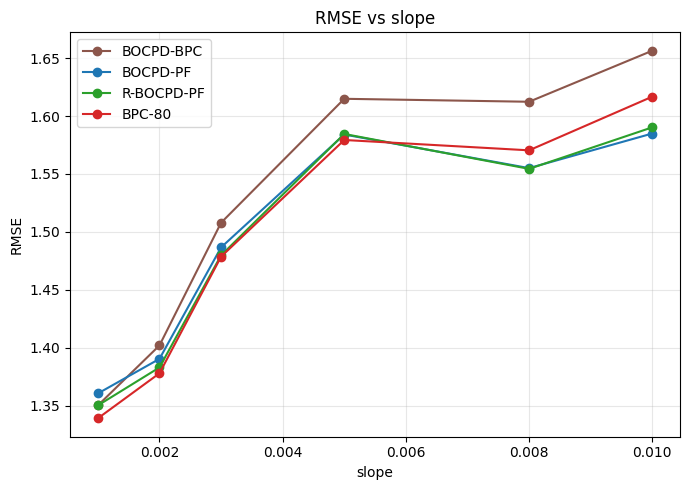

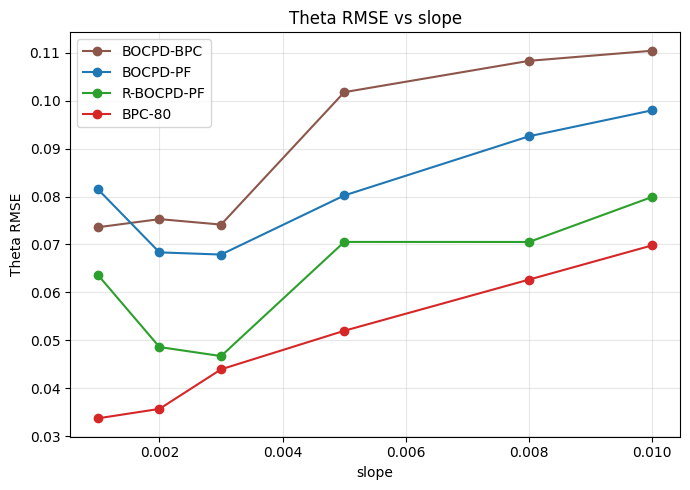

In [187]:
import matplotlib.pyplot as plt

def plot_metric_vs_slope(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("slope")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("slope")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_vs_slope(df, "rmse_mean", "RMSE")
plot_metric_vs_slope(df, "theta_rmse", "Theta RMSE")


In [188]:
def compute_rank(df, metric):
    ranks = []
    for slope in df["slope"].unique():
        d = df[df["slope"]==slope]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                slope=slope,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank(df, "rmse_mean")
rank_theta = compute_rank(df, "theta_rmse")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
BPC-80        1.666667
R-BOCPD-PF    2.166667
BOCPD-PF      2.500000
BOCPD-BPC     3.666667
Name: rank, dtype: float64

Theta RMSE rank:
method
BPC-80        1.000000
R-BOCPD-PF    2.000000
BOCPD-PF      3.166667
BOCPD-BPC     3.833333
Name: rank, dtype: float64
